# Graphics Card Market Analysis - Web Scraping Project

## Project Overview
In this project, you will create a web scraper to collect and analyze graphics card data from Newegg.com's GPU section. You'll use Python, BeautifulSoup, and other relevant libraries to extract key information about graphics cards currently available in the market.

## Learning Objectives
- Implement web scraping techniques using Python and BeautifulSoup
- Handle pagination in web scraping
- Process and structure collected data
- Practice working with real-world data
- Learn to respect website scraping policies and implement delays

## Part 1: Web scrapping
## Required Data to Extract
For each graphics card listing, you must collect:
1. Product Image URL
2. Product Title (e.g., "MSI Ventus GeForce RTX 3060 12GB")
3. Product Details:
   - Manufacturer
   - Model Number
   - Rating (number of stars)
5. Pricing Information:
   - Current Price
   - Original Price (if available)
   - Shipping Information

![Screenshot](image.png)

## Project Requirements

### Technical Requirements
1. Use Python 3.x
2. Required libraries:
   - requests
   - beautifulsoup4
   - pandas
   - time (for implementing delays)

### Functional Requirements
1. Implement proper error handling
2. Include appropriate delays between requests (minimum 2 seconds)
3. Save the scraped data to a CSV file with appropriate column headers
4. Document your code with comments
5. Create a summary of the collected data (e.g., average price, price range)

## Part 2: Data Analysis
### Required Analysis

1. Price Analysis
   - Calculate average price by brand
   - Identify price ranges and market segments
   - Analyze price-to-memory ratio
   - Compare prices across different GPU series (RTX 3000 vs 4000)
   - Create price distribution visualizations

2. Brand Analysis
   - Market share by brand
   - Average ratings by brand
   - Price comparison across brands
   - Create brand comparison visualizations

3. Memory Configuration Analysis
   - Distribution of memory sizes
   - Price correlation with memory size
   - Popular memory configurations by brand

4. Market Segmentation
   - Entry-level vs Mid-range vs High-end segments
   - Price brackets and their features





## Deliverables
1. Python script containing the web scraper
2. CSV file with the collected data
3. README file explaining:
   - Project Description
   - Features
5. Short report analyzing the collected data

## Important Notes
- Always check and respect the website's robots.txt file
- Implement appropriate delays between requests to avoid overwhelming the server
- Handle your requests responsibly and ethically
- Be prepared to handle cases where data might be missing or in an unexpected format

## Part 1: Web scrapping

In [3]:
import time

from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import Select, WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager

import pandas as pd
import selenium
from selenium import webdriver

from tqdm import tqdm

In [12]:
url = "https://www.newegg.com/Desktop-Graphics-Cards/SubCategory/ID-48"

service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--headless=new')
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(5)

gpus = []
page = 1
PAGES_TO_SCRAPE = 20

while page <= PAGES_TO_SCRAPE:
    attempt = 0
    page_products = []

    while attempt < 3:
        driver.get(url + '/Page-' + str(page))
        time.sleep(2)
        products = driver.find_elements(By.CLASS_NAME, 'item-cell')

        if len(products) >= 36:
            page_products = products
            break
        else:
            attempt += 1
            print(f"Page {page} returned {len(products)} products, retrying...")
            time.sleep(3)

    if not page_products:
        print(f"Page {page} failed after 3 attempts, skipping.")
        page += 1
        continue

    for product in tqdm(products, f'Page {page} in progress...'):
        img = product.find_elements(By.CLASS_NAME, 'item-img')
        if img:
            img = img[0].find_element(By.TAG_NAME, 'img').get_attribute('src')
        else:
            img = None

        rating = product.find_elements(By.CLASS_NAME, 'item-rating')
        if rating:
            rating = rating[0].get_attribute('title').split('+ ', 1)[-1]
        else:
            rating = None

        reviews = product.find_elements(By.CLASS_NAME, 'item-rating-num')
        if reviews:
            reviews = reviews[0].text
        else:
            reviews = None

        manufacturer = product.find_elements(By.CLASS_NAME, 'item-brand')
        if manufacturer:
            manufacturer = manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('title') or manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('alt')
        else:
            manufacturer = None

        title = product.find_elements(By.CLASS_NAME, 'item-title')[0].text
        if not title:
            continue

        model = product.find_elements(By.CLASS_NAME, 'item-features')
        if model:
            model_raw = model[0].text
            model_text = model_raw.split(': ', 1)[-1]
        else:
            model_text = None

        price = product.find_elements(By.CLASS_NAME, 'price-current')
        if price:
            price = price[0].text.split(' ', 1)[0]
        else:
            price = None

        shipping_price = product.find_elements(By.CLASS_NAME, 'price-ship')
        if shipping_price:
            shipping_price = shipping_price[0].text
        else:
            shipping_price = None

        original_price = product.find_elements(By.CLASS_NAME, 'price-was')
        if original_price:
            original_price = original_price[0].text
        else:
            original_price = None

        gpu = {
            'img': img,
            'rating': rating,
            'reviews': reviews,
            'manufacturer': manufacturer,
            'title': title,
            'model': model_text,
            'price': price,
            'shipping_price': shipping_price,
            'original_price': original_price
        }
        gpus.append(gpu)

    page+=1

time.sleep(3)
driver.quit()

Page 20 in progress...: 100%|██████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.66it/s]


In [6]:
df = pd.read_csv('newegg.csv')

## Part 2: Data Analysis

In [7]:
import matplotlib.pyplot as plt

In [8]:
df.head()

,img,rating,reviews,manufacturer,title,model,price,shipping_price,original_price
0,https://c1.neweggimages.com/productimage/nb300...,4.7,(125),Sapphire Tech,SAPPHIRE PULSE Radeon RX 9060 XT 16GB GDDR6 PC...,11350-03-20G,$499.99,Free Shipping,NaN
1,https://c1.neweggimages.com/productimage/nb300...,4.7,(111),ASRock,ASRock Challenger Radeon RX 9060 XT 16GB GDDR6...,RX9060XT CL 16GO,$469.99,Free Shipping,$498.49
2,https://c1.neweggimages.com/productimage/nb300...,4.8,(241),GIGABYTE,GIGABYTE Gaming GeForce RTX 5070 Ti 16GB GDDR7...,GV-N507TGAMING OC-16GD,"$1,087.99",Free Shipping,"$1,271.99"
3,https://c1.neweggimages.com/productimage/nb300...,4.6,(139),ASRock,ASRock Challenger Radeon RX 9070 XT 16GB GDDR6...,RX9070XT CL 16G,$719.99,Free Shipping,$763.49
4,https://c1.neweggimages.com/productimage/nb300...,4.5,(74),ASRock,ASRock Challenger Radeon RX 9070 16GB GDDR6 PC...,RX9070 CL 16G,$649.99,Free Shipping,$650.00


### Required Analysis

#### 1. Price Analysis

   - Calculate average price by brand

In [9]:
df = df.replace('', pd.NA).replace('COMING', pd.NA)

In [10]:
df = df.dropna(subset='price')

In [11]:
df['price'] = df['price'].str.replace('$','').str.replace(',', '').astype('float')

In [12]:
avg_price = df.groupby('manufacturer')['price'].mean()
avg_price

manufacturer
AMD               304.325000
ASRock            469.440345
ASUS             1217.600268
GIGABYTE          960.312556
HP                809.000000
Intel             590.000000
Lenovo            231.858000
MSI               852.723391
NVIDIA           1263.403636
PowerColor        677.261429
Sapphire Tech     818.313636
XFX               528.261538
ZOTAC             985.360937
Name: price, dtype: float64

- Identify price ranges and market segments

In [13]:
df['price'].describe()

count     718.000000
mean      880.215084
std       969.541416
min        18.740000
25%       339.000000
50%       598.500000
75%      1064.272500
max      8199.000000
Name: price, dtype: float64

In [65]:
bins = [0, 1200, 4000, float('inf')]
labels = ['Entry-level', 'Mid-range', 'High-end']

In [66]:
df['segment'] = pd.cut(df['price'], bins=bins, labels=labels)
df['segment'].value_counts()

segment
Entry-level    552
Mid-range      140
High-end        15
Name: count, dtype: int64

- Analyze price-to-memory ratio

In [45]:
import re

# Code from Claude using regex, to precisely extract the memory number from
# the title of the product, even if it's written in MB instead of GB.
# The last bit of code drops any memory that goes beyond 48GB,
# as anything above that would've probably been an extracting mistake.
def extract_memory(title):
    if not isinstance(title, str):
        return None
    gb_match = re.search(r'(\d+)\s?GB(?![a-zA-Z])|(\d+)\s?G(?![a-zA-Z])', title)
    if gb_match:
        return float(gb_match.group(1) or gb_match.group(2))
    mb_match = re.search(r'(\d+)\s?MB(?![a-zA-Z])', title)
    if mb_match:
        return float(mb_match.group(1)) / 1024
    return None

df['memory_gb'] = df['title'].apply(extract_memory)

df.loc[df['memory_gb'] > 48, 'memory_gb'] = None
df = df.dropna(subset=['memory_gb'])

In [42]:
df['price_per_gb'] = df['price'] / df['memory_gb']
df['price_per_gb']

0       31.249375
1       29.374375
2       67.999375
3       44.999375
4       40.624375
          ...    
714     49.995000
716    121.812500
717     31.249375
718     52.187500
719    103.750000
Name: price_per_gb, Length: 707, dtype: float64

- Compare prices across different GPU series (RTX 3000 vs 4000)

In [18]:
df['series'] = df['title'].str.extract(r'RTX\s?(\d{4})', expand=False)
df['series']

0       NaN
1       NaN
2      5070
3       NaN
4       NaN
       ... 
715    2060
716    5080
717     NaN
718    5000
719    3080
Name: series, Length: 718, dtype: object

In [19]:
df.groupby('series')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
series,,,,,,,,
2000,1.0,999.000000,NaN,999.00,999.0000,999.000,999.0000,999.00
2060,7.0,551.785714,179.648234,267.50,463.5000,575.000,672.0000,749.00
2070,4.0,450.000000,175.404295,275.00,335.0000,425.000,540.0000,675.00
2080,6.0,738.500000,49.669910,695.00,699.0000,719.500,784.2500,799.00
3050,15.0,310.607333,62.466751,219.99,259.9900,289.590,364.5000,425.90
3060,32.0,521.008438,97.474644,319.99,470.4975,498.475,598.2500,699.00
3070,11.0,566.348182,194.240421,305.00,374.9950,555.840,735.0000,795.00
3080,18.0,684.633889,257.724388,429.99,469.9775,599.990,798.0000,1289.00
3090,13.0,1976.998462,230.253751,1479.99,1935.0000,2099.000,2099.0000,2199.00


- Create price distribution visualizations

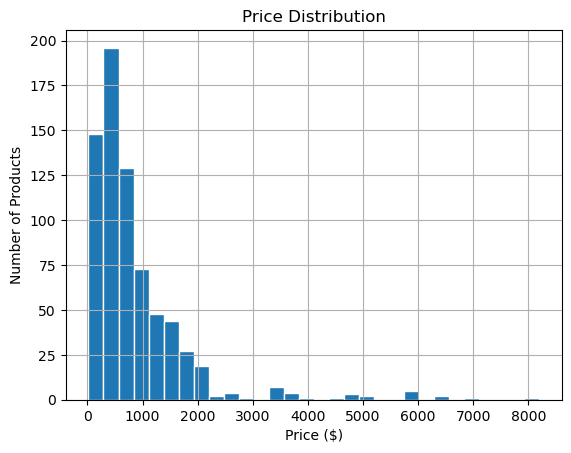

In [20]:
df['price'].hist(bins=30, edgecolor='white')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.title('Price Distribution')
plt.show()

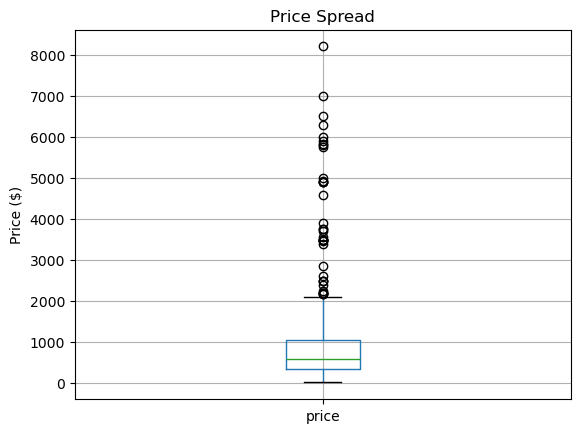

In [21]:
df.boxplot(column='price')
plt.ylabel('Price ($)')
plt.title('Price Spread')
plt.show()

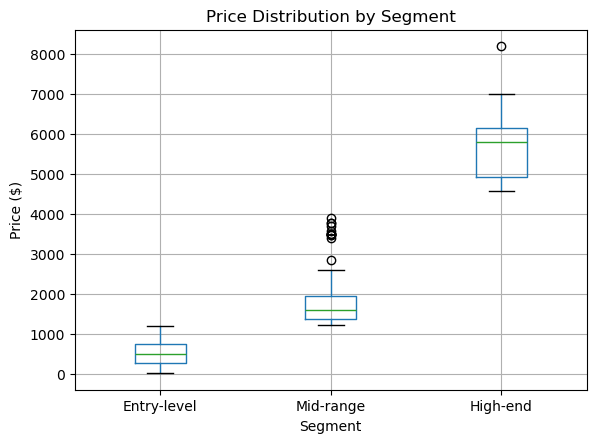

In [67]:
df.boxplot(column='price', by='segment')
plt.xlabel('Segment')
plt.ylabel('Price ($)')
plt.title('Price Distribution by Segment')
plt.suptitle('')
plt.show()

#### 2. Brand Analysis

- Market share by brand

In [24]:
brand_counts = df['manufacturer'].value_counts()
brand_share = (brand_counts / brand_counts.sum() * 100).round(2)
brand_share

manufacturer
ASUS             25.00
GIGABYTE         22.32
MSI              19.30
NVIDIA            7.38
Sapphire Tech     5.54
ZOTAC             5.37
ASRock            4.87
XFX               4.36
PowerColor        3.52
AMD               1.01
Lenovo            0.84
HP                0.34
Intel             0.17
Name: count, dtype: float64

- Average ratings by brand

In [29]:
df['rating'] = pd.to_numeric(df['rating'])
df.groupby('manufacturer')['rating'].mean().sort_values(ascending=False)

manufacturer
AMD              5.000000
Lenovo           5.000000
ASUS             4.656818
XFX              4.652941
NVIDIA           4.642857
MSI              4.560204
GIGABYTE         4.544954
Sapphire Tech    4.500000
ZOTAC            4.443750
ASRock           4.319048
PowerColor       4.283333
HP                    NaN
Intel                 NaN
Name: rating, dtype: float64

- Price comparison across brands

In [30]:
df.groupby('manufacturer')['price'].describe().sort_values('mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
manufacturer,,,,,,,,
NVIDIA,44.0,1263.403636,1619.256512,33.25,349.99,702.78,1557.5000,8199.00
ASUS,149.0,1217.600268,1271.051639,64.49,490.00,829.99,1479.0000,6999.00
ZOTAC,32.0,985.360937,860.635493,99.99,457.49,564.99,1337.2425,3499.00
GIGABYTE,133.0,960.312556,1023.181542,39.99,399.00,620.90,1169.9900,5899.99
MSI,115.0,852.723391,699.352676,44.97,427.50,679.00,1159.9900,4899.99
Sapphire Tech,33.0,818.313636,435.664033,56.00,543.19,789.99,969.0000,1799.99
HP,2.0,809.000000,834.386002,219.00,514.00,809.00,1104.0000,1399.00
PowerColor,21.0,677.261429,313.774008,144.99,469.99,569.99,849.9900,1480.60
Intel,1.0,590.000000,NaN,590.00,590.00,590.00,590.0000,590.00


- Create brand comparison visualizations

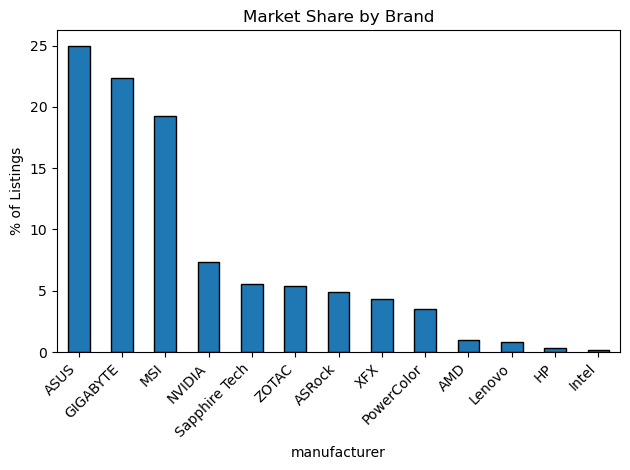

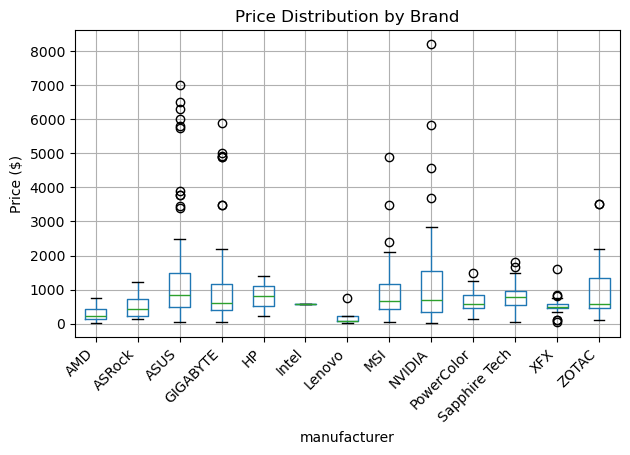

In [31]:
# Market share
brand_share.plot(kind='bar', edgecolor='black')
plt.ylabel('% of Listings')
plt.title('Market Share by Brand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Price by brand
df.boxplot(column='price', by='manufacturer')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Price ($)')
plt.title('Price Distribution by Brand')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### 3. Memory Configuration Analysis

- Distribution of memory sizes

In [43]:
df['memory_gb'].value_counts().sort_index()

memory_gb
0.25       1
0.50       1
1.00      12
1.50       1
2.00      36
3.00       5
4.00      51
5.00       3
6.00      30
8.00     156
10.00     12
11.00      8
12.00    115
16.00    212
20.00      8
24.00     40
32.00     15
48.00      1
Name: count, dtype: int64

- Price correlation with memory size

In [49]:
print(df['price'].corr(df['memory_gb']).round(2))

0.78


- Popular memory configurations by brand

In [55]:
df.groupby(['manufacturer', 'memory_gb']).size().unstack(fill_value=0)

memory_gb,1.0,4.0,8.0,12.0,16.0,6.0,10.0,20.0,24.0,2.0,3.0,5.0,32.0,11.0,48.0
manufacturer,,,,,,,,,,,,,,,
AMD,1,1,1,2,1,0,0,0,0,0,0,0,0,0,0
ASRock,0,1,9,4,9,2,1,1,1,0,0,0,0,0,0
ASUS,1,5,30,30,49,7,2,1,9,6,1,2,6,0,0
GIGABYTE,0,9,35,23,35,6,1,0,6,8,1,0,5,2,0
HP,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Intel,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Lenovo,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0
MSI,4,5,32,21,35,5,3,0,2,5,0,0,1,2,0
NVIDIA,1,2,6,4,12,0,1,2,8,1,0,0,3,1,1


#### 4. Market Segmentation

- Entry-level vs Mid-range vs High-end segments

In [68]:
df.groupby('segment', observed=False)['price'].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Entry-level,552.0,516.704656,292.962496,18.74,284.4975,490.495,755.250,1199.99
Mid-range,140.0,1812.453286,638.661196,1215.00,1385.2850,1604.995,1961.250,3895.00
High-end,15.0,5765.540000,973.990808,4580.00,4914.9900,5799.990,6149.495,8199.00


- Price brackets and their features

In [69]:
df.groupby('segment', observed=False)['memory_gb'].mean()

segment
Entry-level     9.775815
Mid-range      17.742857
High-end       33.066667
Name: memory_gb, dtype: float64